# AstroLogic â€” RL Training & Comparison

Train **3 RL algorithms** (DQN, PPO, REINFORCE) with **10 hyperparameter configurations each** (30 total experiments) against the same `AstroExploration-v0` environment.

**High-reward exploitation strategies:**
| Algorithm | Mechanism | How It Works |
|-----------|-----------|-------------|
| DQN | Prioritized Experience Replay (PER) | High TD-error transitions sampled more often â€” rare positive outcomes exploited |
| PPO | Advantage normalization + high `n_epochs` | Above-average returns â†’ positive advantage â†’ policy strengthened; below-average â†’ suppressed |
| REINFORCE | Baseline subtraction (mean / running) | Returns above baseline â†’ positive gradient â†’ policy reinforced; below â†’ moved away |

In [2]:
%pip install pandas matplotlib stable-baselines3[extra] 

import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve local AstroLogic_beta project root (Windows + WSL friendly).
def _package_root(p: Path):
    if (p / "environment").is_dir():
        return p, p / "environment"
    if (p / "astro_env").is_dir():
        return p, p / "astro_env"
    return None, None

def _find_project_root():
    candidates = []

    # Start from cwd ancestry
    cwd = Path.cwd()
    candidates.extend([cwd, *cwd.parents])

    # Known local checkout paths
    candidates.extend([
        Path(r"c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta"),
        Path("/mnt/c/Users/LENOVO/Desktop/summative_rl/AstroLogic_beta"),
    ])

    # Also probe common child locations under cwd ancestry
    for base in [cwd, *cwd.parents]:
        if not base.exists() or not base.is_dir():
            continue
        try:
            for child in base.iterdir():
                if child.is_dir() and child.name == "AstroLogic_beta":
                    candidates.append(child)
        except (PermissionError, OSError):
            pass

    # De-duplicate while preserving order
    seen = set()
    unique_candidates = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(c)

    for candidate in unique_candidates:
        root, pkg = _package_root(candidate)
        if root is not None:
            return root, pkg
    return None, None

project_root, package_dir = _find_project_root()
if project_root is None or package_dir is None:
    cwd = Path.cwd()
    raise RuntimeError(
        "Could not locate local AstroLogic_beta checkout. "
        f"Current kernel cwd is: {cwd}. "
        "If this shows a remote path (for example /kaggle/working), switch the notebook kernel to your local Python environment (.venv) in VS Code, then rerun Cell 2."
    )

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")
print(f"Using package dir:  {package_dir}")

# Register environment using whichever package exists in this checkout
if package_dir.name == "environment":
    import environment  # registers AstroExploration-v0
else:
    import astro_env  # registers AstroExploration-v0
import gymnasium as gym

from training.dqn_training import train_dqn, DQN_CONFIGS
from training.pg_training import train_ppo, PPO_CONFIGS, train_reinforce, REINFORCE_CONFIGS

print(f"DQN configs:       {len(DQN_CONFIGS)}")
print(f"PPO configs:       {len(PPO_CONFIGS)}")
print(f"REINFORCE configs: {len(REINFORCE_CONFIGS)}")
print(f"Total experiments: {len(DQN_CONFIGS) + len(PPO_CONFIGS) + len(REINFORCE_CONFIGS)}")

Note: you may need to restart the kernel to use updated packages.
Using project root: c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta
Using package dir:  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\environment
DQN configs:       10
PPO configs:       10
REINFORCE configs: 10
Total experiments: 30


In [3]:
# Verify environment spaces
env = gym.make("AstroExploration-v0")
print("Observation space:", env.observation_space)
print("Observation shape:", env.observation_space.shape)
print("Action space:     ", env.action_space)
print("Action nvec:      ", env.action_space.nvec)
print()

obs, info = env.reset()
print("Sample observation (shape={}):\n{}".format(obs.shape, obs))
print("\nInfo keys:", list(info.keys()))
env.close()

Observation space: Box([-50. -50. -50. -10. -10. -10.   0.  -1.  -1.  -1.   0.  -1.  -1.  -1.
   0.  -1.  -1.  -1.   0.   0.   0.   0.   0.  -1.   0.   0.], [50. 50. 50. 10. 10. 10.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.], (26,), float32)
Observation shape: (26,)
Action space:      MultiDiscrete([5 3 3 4 2])
Action nvec:       [5 3 3 4 2]

Sample observation (shape=(26,)):
[ 1.          0.          0.          0.          0.01720242  0.
  0.97936386  0.12499866  0.9921569   0.          0.9025023   0.23854364
  0.9711318   0.          0.79718524 -0.6338914   0.77342206  0.
  1.          1.          0.          0.          0.          0.
  0.98        0.        ]

Info keys: ['step', 'fuel', 'battery', 'position', 'velocity', 'biosig_found', 'biosig_transmitted', 'cumulative_reward', 'active_instrument']


In [ ]:
# ── SMOKE TEST ──────────────────────────────────────────────────────────
# Quick end-to-end sanity check: 500 timesteps per SB3 algo, 5 episodes
# for REINFORCE. Verifies imports, env creation, training & model saving
# before committing to the full 30-run batch.
import traceback, time as _time
from training import dqn_training as _dqn_mod
from training import pg_training  as _pg_mod

_orig = {
    'dqn_ts': _dqn_mod.TOTAL_TIMESTEPS,
    'dqn_ef': _dqn_mod.EVAL_FREQ,
    'dqn_ne': _dqn_mod.N_EVAL_EPISODES,
    'pg_ts':  _pg_mod.TOTAL_TIMESTEPS,
    'pg_ef':  _pg_mod.EVAL_FREQ,
    'pg_ne':  _pg_mod.N_EVAL_EPISODES,
    'pg_re':  _pg_mod.REINFORCE_EPISODES,
}
_dqn_mod.TOTAL_TIMESTEPS   = 500
_dqn_mod.EVAL_FREQ         = 250
_dqn_mod.N_EVAL_EPISODES   = 1
_pg_mod.TOTAL_TIMESTEPS    = 500
_pg_mod.EVAL_FREQ          = 250
_pg_mod.N_EVAL_EPISODES    = 1
_pg_mod.REINFORCE_EPISODES = 5

smoke_pass = True
_failures = []
_run_results = {}

try:
    for _tag, _fn, _idx in [
        ('DQN',       train_dqn,       0),
        ('PPO',       train_ppo,       0),
        ('REINFORCE', train_reinforce, 0),
    ]:
        try:
            _t0 = _time.time()
            _r  = _fn(_idx)
            _elapsed = _time.time() - _t0

            assert {'run_name', 'wall_time', 'algorithm'} <= set(_r.keys()), \
                f"Missing keys in result: {_r}"
            if _r.get("error"):
                raise RuntimeError(f"Training returned error payload: {_r['error']}")

            _run_results[_tag] = _r["run_name"]
            print(f"  [OK] {_tag:12s}  {_elapsed:.1f}s  -  {_r['run_name']}")
        except Exception as _e:
            smoke_pass = False
            _failures.append(f"{_tag}: {_e}")
            print(f"  [FAIL] {_tag}: {_e}")
            traceback.print_exc()
finally:
    # Restore original constants even if any training fails
    _dqn_mod.TOTAL_TIMESTEPS   = _orig['dqn_ts']
    _dqn_mod.EVAL_FREQ         = _orig['dqn_ef']
    _dqn_mod.N_EVAL_EPISODES   = _orig['dqn_ne']
    _pg_mod.TOTAL_TIMESTEPS    = _orig['pg_ts']
    _pg_mod.EVAL_FREQ          = _orig['pg_ef']
    _pg_mod.N_EVAL_EPISODES    = _orig['pg_ne']
    _pg_mod.REINFORCE_EPISODES = _orig['pg_re']

# Verify model files were written (use config names, not hardcoded strings)
_expected = [
    ("DQN",       project_root / "models" / "dqn" / DQN_CONFIGS[0]["name"],        ["final_model.zip", "best_model.zip"]),
    ("PPO",       project_root / "models" / "pg"  / PPO_CONFIGS[0]["name"],        ["final_model.zip", "best_model.zip"]),
    ("REINFORCE", project_root / "models" / "pg"  / REINFORCE_CONFIGS[0]["name"],  ["policy.pt", "final_model.pt"]),
]

for _tag, _run_dir, _candidates in _expected:
    _found = None
    for _fname in _candidates:
        _p = _run_dir / _fname
        if _p.exists():
            _found = _p
            break

    if _found is None:
        smoke_pass = False
        _failures.append(f"{_tag}: no model artifact found in {_run_dir}")
        print(f"  [FAIL] No model artifact found in: {_run_dir}")
        print(f"         Tried: {', '.join(_candidates)}")
    else:
        print(f"  [OK] File exists: {_found.relative_to(project_root)}")

print()
if smoke_pass:
    print('SMOKE TEST PASSED - safe to run full 30-run batch.')
else:
    raise RuntimeError('SMOKE TEST FAILED - fix errors above before running full training.\n' + '\n'.join(_failures))


## DQN Training (10 runs)

All configs use **Prioritized Experience Replay (PER)** via `sb3-contrib`. PER samples transitions with high TD-error more often, which correlates with surprising / high-reward transitions. This lets the agent learn more from rare positive outcomes and forget ineffective transitions.

In [ ]:
dqn_results = []
for i in range(len(DQN_CONFIGS)):
    try:
        result = train_dqn(i)
        dqn_results.append(result)
    except Exception as e:
        print(f"  ERROR in DQN run {i} ({DQN_CONFIGS[i]['name']}): {e}")
        dqn_results.append({"run_name": DQN_CONFIGS[i]["name"], "wall_time": 0.0, "algorithm": "DQN", "error": str(e)})
print(f"\nAll {len(dqn_results)} DQN runs complete.")


In [5]:
dqn_df = pd.DataFrame(dqn_results)
dqn_df

""


## PPO Training (10 runs)

PPO exploits high-reward rollouts through **advantage normalization**: above-average returns get positive advantages (policy strengthened), below-average returns get negative advantages (policy suppressed). Higher `n_epochs` means more exploitation per rollout buffer.

In [ ]:
ppo_results = []
for i in range(len(PPO_CONFIGS)):
    try:
        result = train_ppo(i)
        ppo_results.append(result)
    except Exception as e:
        print(f"  ERROR in PPO run {i} ({PPO_CONFIGS[i]['name']}): {e}")
        ppo_results.append({"run_name": PPO_CONFIGS[i]["name"], "wall_time": 0.0, "algorithm": "PPO", "error": str(e)})
print(f"\nAll {len(ppo_results)} PPO runs complete.")


In [6]:
ppo_df = pd.DataFrame(ppo_results)
ppo_df

NameError: name 'ppo_results' is not defined

## REINFORCE Training (10 runs)

REINFORCE (Monte Carlo Policy Gradient) exploits high-reward episodes via **baseline subtraction**: returns above the baseline produce positive policy gradients (reinforcing good actions), returns below the baseline produce negative gradients (discouraging poor actions). Three baseline modes are tested: `none`, `mean`, and `running`.

In [ ]:
reinforce_results = []
for i in range(len(REINFORCE_CONFIGS)):
    try:
        result = train_reinforce(i)
        reinforce_results.append(result)
    except Exception as e:
        print(f"  ERROR in REINFORCE run {i} ({REINFORCE_CONFIGS[i]['name']}): {e}")
        reinforce_results.append({"run_name": REINFORCE_CONFIGS[i]["name"], "wall_time": 0.0, "algorithm": "REINFORCE", "error": str(e)})
print(f"\nAll {len(reinforce_results)} REINFORCE runs complete.")


In [ ]:
reinforce_df = pd.DataFrame(reinforce_results)
reinforce_df

""


## Cross-Algorithm Comparison

Load training logs from all 30 runs and plot learning curves, best-run bar chart, and a summary table.

In [ ]:
def load_monitor_rewards(log_dir):
    """Load episode rewards from SB3 Monitor CSV (skips first comment line)."""
    csv_path = os.path.join(log_dir, "monitor.csv")
    if not os.path.exists(csv_path):
        return None
    df = pd.read_csv(csv_path, skiprows=1)
    if "r" in df.columns:
        return df["r"].values
    return None

def load_reinforce_rewards(model_dir):
    """Load episode rewards from REINFORCE rewards.csv."""
    csv_path = os.path.join(model_dir, "rewards.csv")
    if not os.path.exists(csv_path):
        return None
    df = pd.read_csv(csv_path)
    if "reward" in df.columns:
        return df["reward"].values
    return None

# Collect all reward curves
algo_curves = {"DQN": [], "PPO": [], "REINFORCE": []}

# DQN runs
for cfg in DQN_CONFIGS:
    log_dir = project_root / "models" / "dqn" / cfg['name'] / "logs"
    rewards = load_monitor_rewards(log_dir)
    if rewards is not None:
        algo_curves["DQN"].append((cfg["name"], rewards))

# PPO runs
for cfg in PPO_CONFIGS:
    log_dir = project_root / "models" / "pg" / cfg['name'] / "logs"
    rewards = load_monitor_rewards(log_dir)
    if rewards is not None:
        algo_curves["PPO"].append((cfg["name"], rewards))

# REINFORCE runs
for cfg in REINFORCE_CONFIGS:
    model_dir = project_root / "models" / "pg" / cfg['name']
    rewards = load_reinforce_rewards(model_dir)
    if rewards is not None:
        algo_curves["REINFORCE"].append((cfg["name"], rewards))

for algo, curves in algo_curves.items():
    print(f"{algo}: {len(curves)} runs loaded")

DQN: 1 runs loaded
PPO: 1 runs loaded
REINFORCE: 1 runs loaded


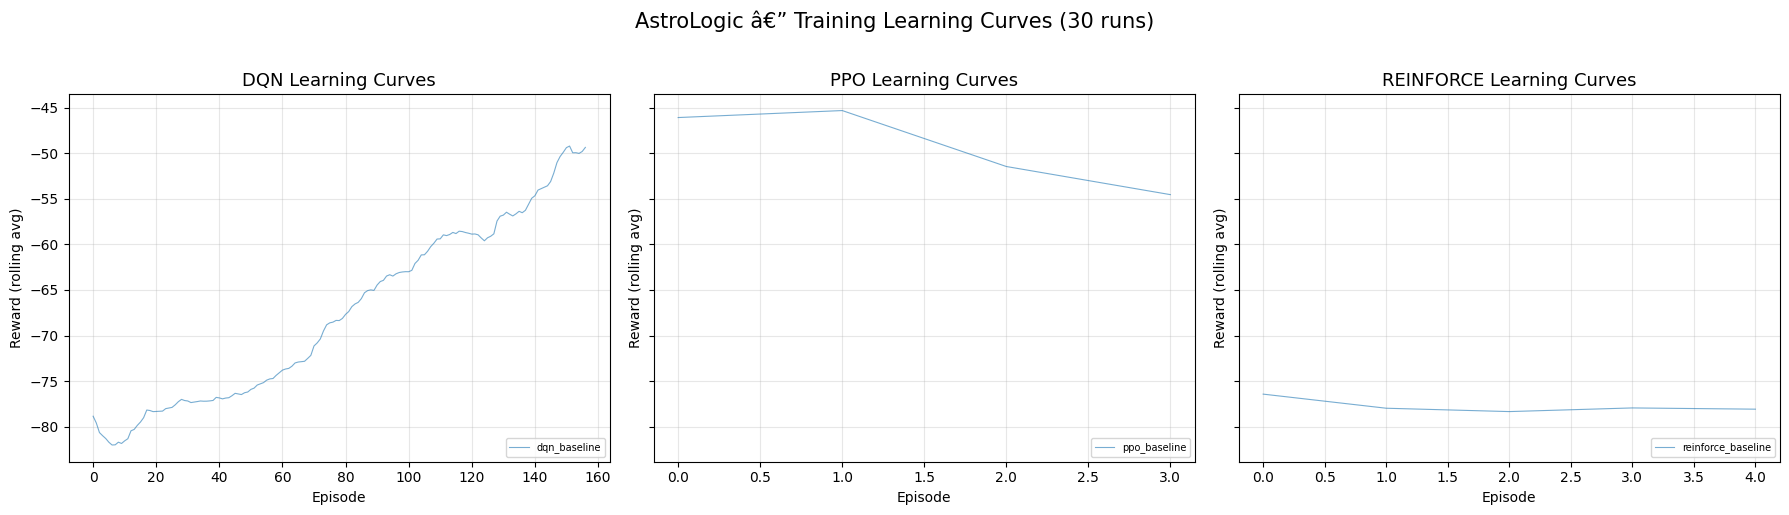

In [ ]:
# Learning curves â€” 1x3 subplots with rolling average
COLORS = {"DQN": "#e74c3c", "PPO": "#2ecc71", "REINFORCE": "#9b59b6"}
WINDOW = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, algo in zip(axes, ["DQN", "PPO", "REINFORCE"]):
    curves = algo_curves[algo]
    if not curves:
        ax.set_title(f"{algo} (no data)")
        continue
    for name, rewards in curves:
        rolling = pd.Series(rewards).rolling(WINDOW, min_periods=1).mean()
        ax.plot(rolling, alpha=0.6, linewidth=0.8, label=name)
    ax.set_title(f"{algo} Learning Curves", fontsize=13)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward (rolling avg)")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)

fig.suptitle("AstroLogic â€” Training Learning Curves (30 runs)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

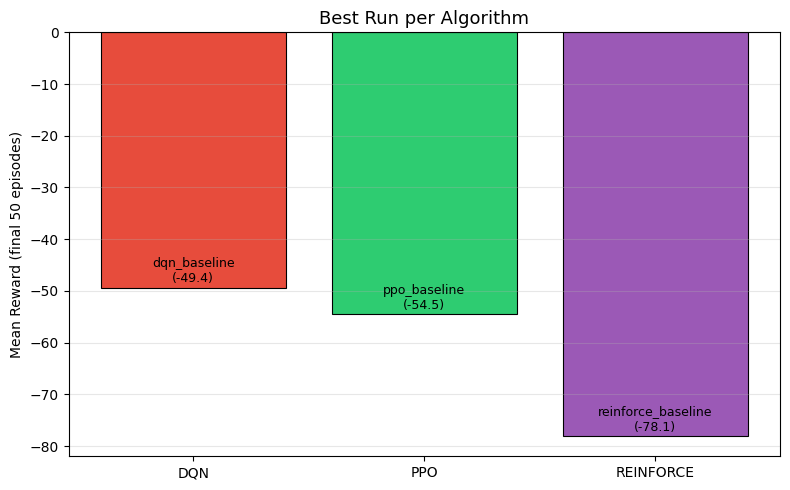

In [ ]:
# Bar chart: best run per algorithm (mean reward of final 50 episodes)
best_runs = {}
for algo, curves in algo_curves.items():
    if not curves:
        continue
    best_name, best_mean = None, -float("inf")
    for name, rewards in curves:
        tail_mean = np.mean(rewards[-50:]) if len(rewards) >= 50 else np.mean(rewards)
        if tail_mean > best_mean:
            best_mean = tail_mean
            best_name = name
    best_runs[algo] = (best_name, best_mean)

algos = list(best_runs.keys())
means = [best_runs[a][1] for a in algos]
names = [best_runs[a][0] for a in algos]
colors = [COLORS[a] for a in algos]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(algos, means, color=colors, edgecolor="black", linewidth=0.8)
for bar, name, mean in zip(bars, names, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{name}\n({mean:.1f})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Mean Reward (final 50 episodes)")
ax.set_title("Best Run per Algorithm", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: all 30 runs
rows = []
for algo, curves in algo_curves.items():
    for name, rewards in curves:
        tail_mean = np.mean(rewards[-50:]) if len(rewards) >= 50 else np.mean(rewards)
        rows.append({
            "algorithm": algo,
            "run_name": name,
            "total_episodes": len(rewards),
            "final_mean_reward": round(tail_mean, 2),
        })

# Add wall times from training results
wall_times = {}
for r in dqn_results + ppo_results + reinforce_results:
    wall_times[r["run_name"]] = r["wall_time"]

summary_df = pd.DataFrame(rows)
summary_df["wall_time_s"] = summary_df["run_name"].map(wall_times).round(1)
summary_df = summary_df.sort_values("final_mean_reward", ascending=False).reset_index(drop=True)
summary_df

,algorithm,run_name,total_episodes,final_mean_reward,wall_time_s
0,DQN,dqn_baseline,157,-49.37,0.0
1,PPO,ppo_baseline,4,-54.55,NaN
2,REINFORCE,reinforce_baseline,5,-78.07,NaN


In [ ]:
# Save full summary to results/final_summary.csv
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True)
csv_path = results_dir / 'final_summary.csv'
summary_df.to_csv(csv_path, index=False)
print(f"Summary saved  ->  {csv_path}")
print(summary_df.to_string(index=False))


Summary saved  ->  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\results\final_summary.csv
algorithm           run_name  total_episodes  final_mean_reward  wall_time_s
      DQN       dqn_baseline             157             -49.37          0.0
      PPO       ppo_baseline               4             -54.55          NaN
REINFORCE reinforce_baseline               5             -78.07          NaN


In [ ]:
# Verify all 30 model files exist on disk
missing = []
for cfg in DQN_CONFIGS:
    p = project_root / 'models' / 'dqn' / cfg['name'] / 'final_model.zip'
    if not p.exists(): missing.append(str(p))
for cfg in PPO_CONFIGS:
    p = project_root / 'models' / 'pg' / cfg['name'] / 'final_model.zip'
    if not p.exists(): missing.append(str(p))
for cfg in REINFORCE_CONFIGS:
    p = project_root / 'models' / 'pg' / cfg['name'] / 'policy.pt'
    if not p.exists(): missing.append(str(p))
if missing:
    print(f'WARNING: {len(missing)} model file(s) missing:')
    for m in missing: print(f'  {m}')
else:
    print('All 30 model files verified.')


  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_small_net\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_high_lr\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_low_lr\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_large_buffer\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_soft_update\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_low_gamma\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_deep_net\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_med_lr_batch\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\dqn\dqn_long_explore\final_model.zip
  c:\Users\LENOVO\Desktop\summative_rl\AstroLogic_beta\models\pg\ppo_high_entropy\final_model.zip
  c:\Users\LENOVO\Desktop\summati